In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Import Libraries PyTorch

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f'TensorFlow version : {tf.__version__}')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
print(f'PyTorch version    : {torch.__version__}')
print(f'CUDA available     : {torch.cuda.is_available()}')

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device     : {device}')

TensorFlow version : 2.20.0
PyTorch version    : 2.8.0+cpu
CUDA available     : False
PyTorch device     : cpu


# Load and Prepare Data

In [19]:
# ── Keras version ──────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train_flat = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test_flat  = x_test.reshape(-1, 784).astype('float32') / 255.0

# Keep 2-D version for CNN
x_train_cnn = x_train[..., np.newaxis].astype('float32') / 255.0
x_test_cnn  = x_test[..., np.newaxis].astype('float32') / 255.0

# One-hot encode labels for Keras
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test,  10)

print('=== Dataset shapes (Keras) ===')
print(f'x_train : {x_train_flat.shape}  y_train : {y_train_oh.shape}')
print(f'x_test  : {x_test_flat.shape}   y_test  : {y_test_oh.shape}')

# Dataset summary as a DataFrame
summary = pd.DataFrame({
    'Split':   ['Train', 'Test'],
    'Samples': [len(x_train), len(x_test)],
    'Shape':   [str(x_train.shape[1:]), str(x_test.shape[1:])],
    'Classes': [len(np.unique(y_train)), len(np.unique(y_test))]
})
print('\n', summary.to_string(index=False))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Dataset shapes (Keras) ===
x_train : (60000, 784)  y_train : (60000, 10)
x_test  : (10000, 784)   y_test  : (10000, 10)

 Split  Samples    Shape  Classes
Train    60000 (28, 28)       10
 Test    10000 (28, 28)       10


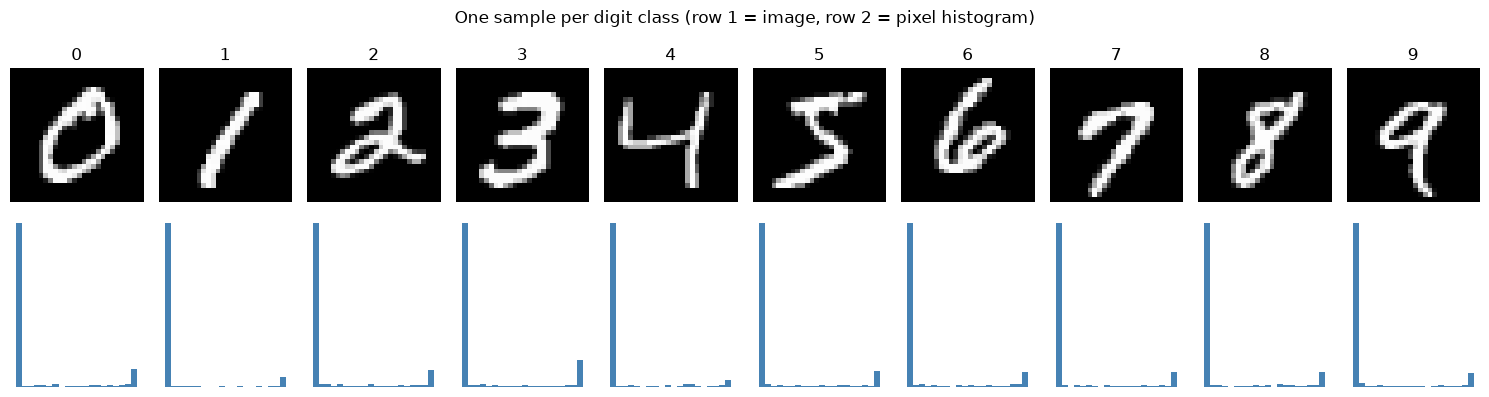

In [20]:
# Visualise sample digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(x_train[idx], cmap='gray')
    axes[0, digit].set_title(str(digit))
    axes[0, digit].axis('off')
    axes[1, digit].hist(x_train[idx].flatten(), bins=20, color='steelblue')
    axes[1, digit].axis('off')
axes[0, 0].set_ylabel('Image',   fontsize=10)
axes[1, 0].set_ylabel('Pixel\ndist.', fontsize=9)
plt.suptitle('One sample per digit class (row 1 = image, row 2 = pixel histogram)', fontsize=12)
plt.tight_layout()
plt.show()

# Define Neural Network Architectures 

### Architecture — Feed-Forward Neural Network (Keras)

In [21]:
def build_keras_ffnn(hidden_units=(128, 64), dropout_rate=0.2, learning_rate=0.001):
    """Build a configurable feed-forward NN with Keras Sequential API."""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(hidden_units[0], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ], name='FFNN_Keras')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

keras_ffnn = build_keras_ffnn()
keras_ffnn.summary()

2026-05-27 18:18:10.971415: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "FFNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Architecture — CNN (Keras)

In [22]:
def build_keras_cnn(learning_rate=0.001):
    """Build a small CNN with the Keras Functional API."""
    inputs = keras.Input(shape=(28, 28, 1), name='input')
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='CNN_Keras')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

keras_cnn = build_keras_cnn()
keras_cnn.summary()

Model: "CNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

## Train Keras Models

In [23]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

BATCH_SIZE = 64
EPOCHS     = 15

print('Training Keras FFNN ...')
hist_ffnn = keras_ffnn.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining Keras CNN ...')
hist_cnn_keras = keras_cnn.fit(
    x_train_cnn, y_train_oh,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Training Keras FFNN ...
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8845 - loss: 0.3883 - val_accuracy: 0.9635 - val_loss: 0.1203 - learning_rate: 0.0010
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9462 - loss: 0.1830 - val_accuracy: 0.9715 - val_loss: 0.0941 - learning_rate: 0.0010
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9579 - loss: 0.1403 - val_accuracy: 0.9725 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9665 - loss: 0.1133 - val_accuracy: 0.9772 - val_loss: 0.0792 - learning_rate: 0.0010
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9691 - loss: 0.0986 - val_accuracy: 0.9772 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9731 - loss: 0.0877 - val_accuracy: 0.9758 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 

## Accuracy & Loss Curves (Keras)

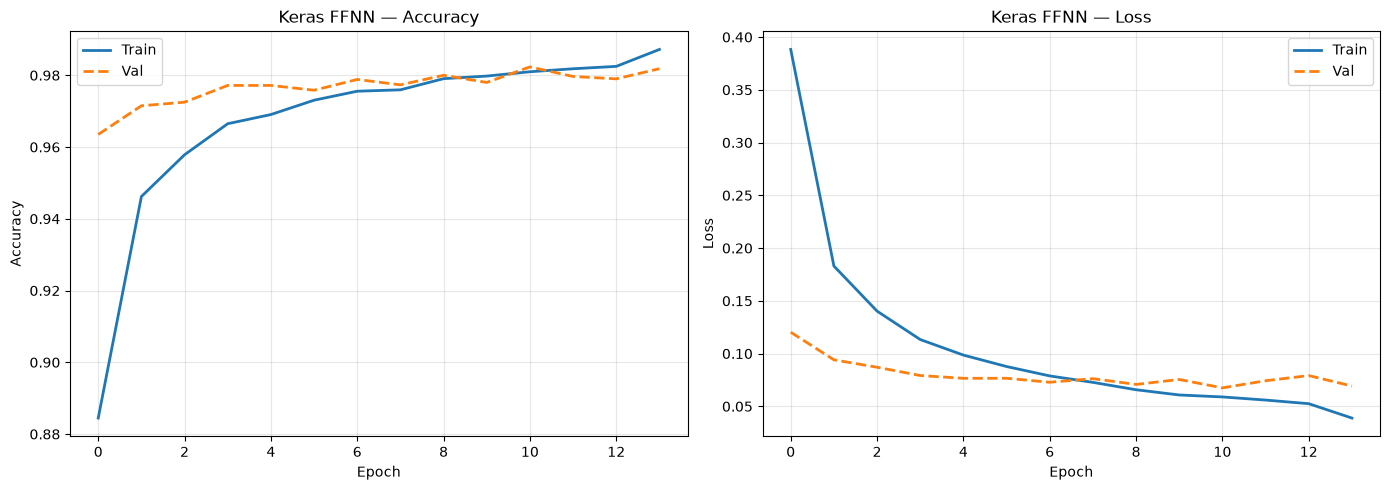

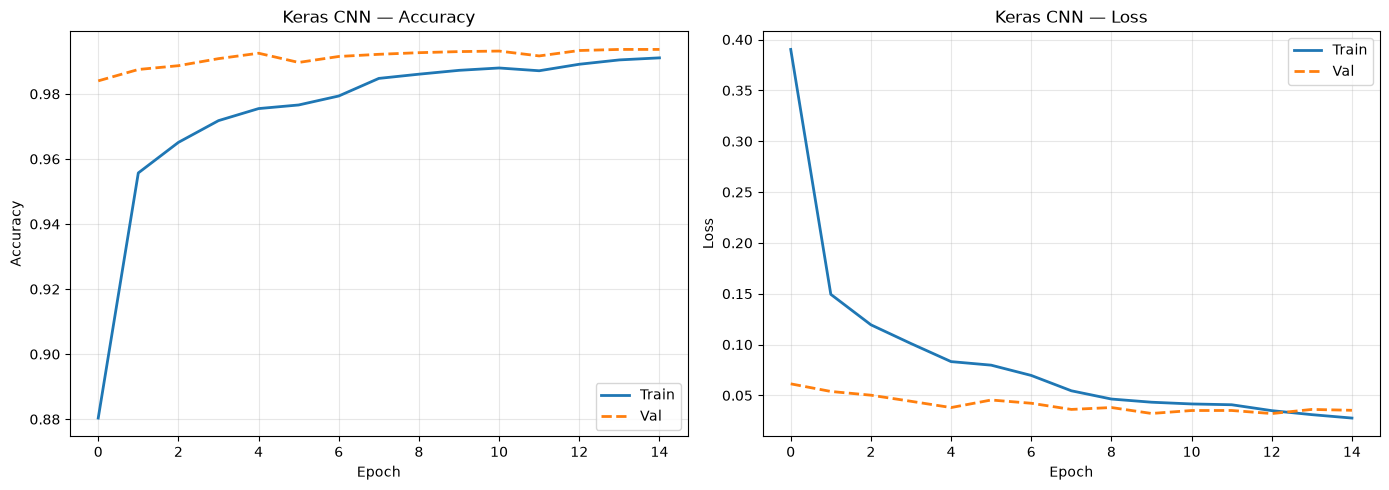

In [24]:
def plot_history(history, title):
    """Plot training and validation accuracy / loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(hist_ffnn,      'Keras FFNN')
plot_history(hist_cnn_keras, 'Keras CNN')

## Evaluate Keras Models


Keras FFNN — Test Loss: 0.0735 | Test Accuracy: 97.87%


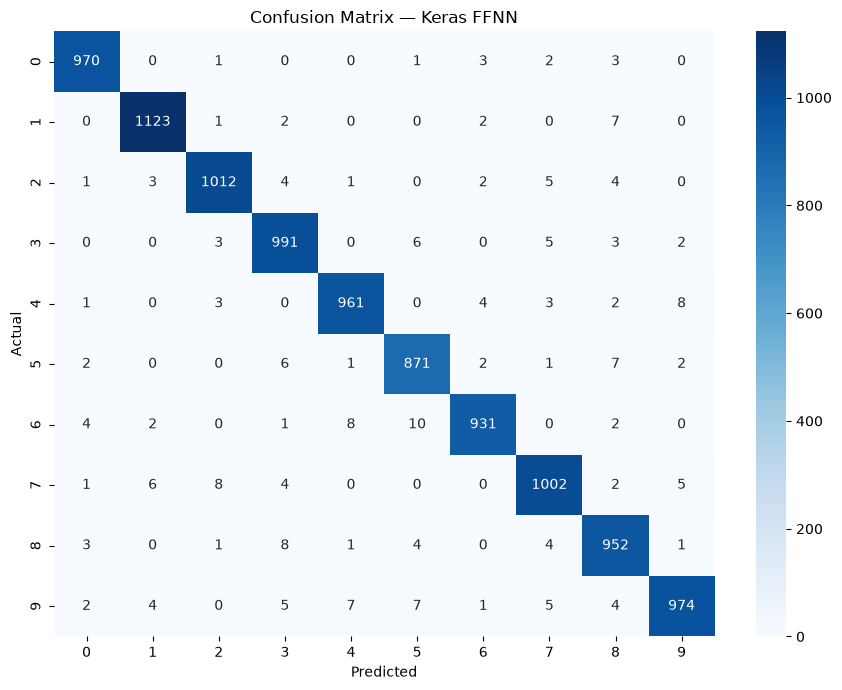


Classification Report — Keras FFNN:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.97       892
           6       0.99      0.97      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Keras CNN — Test Loss: 0.0228 | Test Accuracy: 99.35%


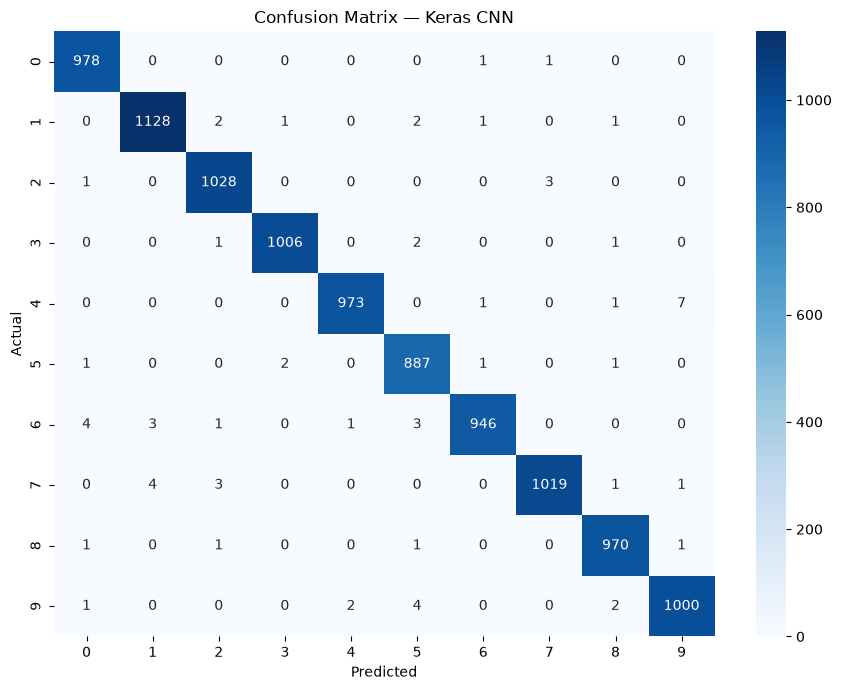


Classification Report — Keras CNN:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [25]:
def evaluate_keras(model, x_test, y_test_oh, y_test_true, model_name):
    loss, acc = model.evaluate(x_test, y_test_oh, verbose=0)
    print(f'\n{model_name} — Test Loss: {loss:.4f} | Test Accuracy: {acc*100:.2f}%')

    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_test_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    print(f'\nClassification Report — {model_name}:')
    print(classification_report(y_test_true, y_pred))
    return acc

acc_ffnn_keras = evaluate_keras(keras_ffnn, x_test_flat, y_test_oh, y_test, 'Keras FFNN')
acc_cnn_keras  = evaluate_keras(keras_cnn,  x_test_cnn,  y_test_oh, y_test, 'Keras CNN')

##  Hyperparameter Tuning (Keras)

We sweep three hyperparameters independently: **learning rate**, **batch size**, and **dropout rate**.
Each experiment trains for 5 epochs so the comparison is fast but indicative.

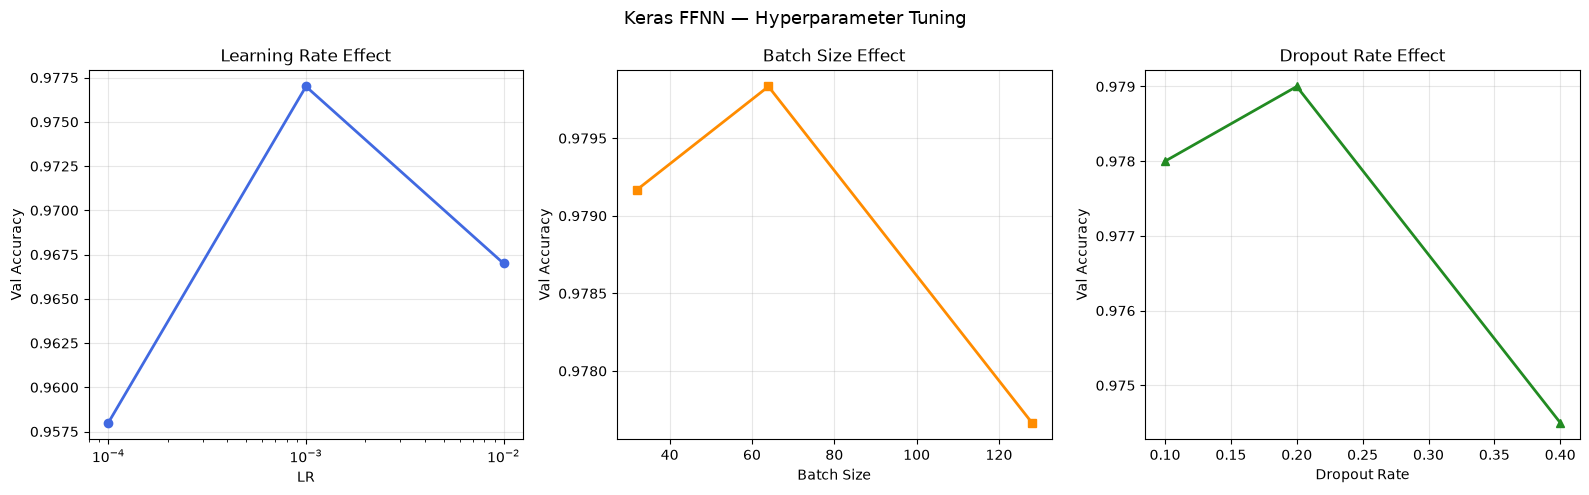


=== Tuning Results ===
             LR     Batch  Dropout
0.0001    0.958       NaN      NaN
0.0010    0.977       NaN      NaN
0.0100    0.967       NaN      NaN
0.1000      NaN       NaN   0.9780
0.2000      NaN       NaN   0.9790
0.4000      NaN       NaN   0.9745
32.0000     NaN  0.979167      NaN
64.0000     NaN  0.979833      NaN
128.0000    NaN  0.977667      NaN


In [26]:
def quick_train_keras(learning_rate=0.001, batch_size=64, dropout_rate=0.2, epochs=5):
    """Train a fresh FFNN with given hyperparameters and return val accuracy."""
    model = build_keras_ffnn(dropout_rate=dropout_rate, learning_rate=learning_rate)
    hist = model.fit(
        x_train_flat, y_train_oh,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    return max(hist.history['val_accuracy'])

# Learning-rate sweep
lr_values   = [0.01, 0.001, 0.0001]
lr_results  = {lr: quick_train_keras(learning_rate=lr) for lr in lr_values}

# Batch-size sweep
bs_values   = [32, 64, 128]
bs_results  = {bs: quick_train_keras(batch_size=bs) for bs in bs_values}

# Dropout sweep
dr_values   = [0.1, 0.2, 0.4]
dr_results  = {dr: quick_train_keras(dropout_rate=dr) for dr in dr_values}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(lr_values, list(lr_results.values()), 'o-', linewidth=2, color='royalblue')
axes[0].set_xscale('log')
axes[0].set_title('Learning Rate Effect'); axes[0].set_xlabel('LR'); axes[0].set_ylabel('Val Accuracy'); axes[0].grid(alpha=0.3)

axes[1].plot(bs_values, list(bs_results.values()), 's-', linewidth=2, color='darkorange')
axes[1].set_title('Batch Size Effect');    axes[1].set_xlabel('Batch Size');    axes[1].set_ylabel('Val Accuracy'); axes[1].grid(alpha=0.3)

axes[2].plot(dr_values, list(dr_results.values()), '^-', linewidth=2, color='forestgreen')
axes[2].set_title('Dropout Rate Effect');  axes[2].set_xlabel('Dropout Rate');  axes[2].set_ylabel('Val Accuracy'); axes[2].grid(alpha=0.3)

plt.suptitle('Keras FFNN — Hyperparameter Tuning', fontsize=13)
plt.tight_layout()
plt.show()

print('\n=== Tuning Results ===')
results_df = pd.DataFrame({
    'LR':      pd.Series(lr_results),
    'Batch':   pd.Series(bs_results),
    'Dropout': pd.Series(dr_results)
})
print(results_df.to_string())


## PyTorch Implementation

We re-implement the same two architectures in PyTorch for comparison.

### Data Loaders (PyTorch)

In [27]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

BATCH_SIZE_PT = 64

train_dataset = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_PT, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_PT, shuffle=False)

print(f'Train: {len(train_dataset)} samples | Test: {len(test_dataset)} samples')

Train: 60000 samples | Test: 10000 samples


## Model Definitions (PyTorch)

In [28]:
class SimpleNN(nn.Module):
    def __init__(self, hidden=(128, 64), dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden[0], hidden[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden[1], 10)
        )
    def forward(self, x): return self.net(x)


class CNN(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(dropout),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(dropout),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))


simple_nn = SimpleNN().to(device)
cnn_pt    = CNN().to(device)
print('SimpleNN params:', sum(p.numel() for p in simple_nn.parameters()))
print('CNN params     :', sum(p.numel() for p in cnn_pt.parameters()))

SimpleNN params: 109386
CNN params     : 390858


## Training & Evaluation Helpers (PyTorch)

In [29]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += model(data).argmax(1).eq(target).sum().item()
        total      += target.size(0)
    return total_loss / len(loader), 100. * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            out = model(data)
            total_loss += criterion(out, target).item()
            preds = out.argmax(1)
            correct += preds.eq(target).sum().item()
            total   += target.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    return total_loss / len(loader), 100. * correct / total, all_preds, all_targets


def train_pytorch(model, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history   = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc       = train_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc, _, _ = eval_epoch(model, test_loader, criterion)
        scheduler.step(te_loss)
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss);  history['test_acc'].append(te_acc)
        print(f'Epoch {epoch:02d} | Train {tr_acc:.2f}% / {tr_loss:.4f} | Test {te_acc:.2f}% / {te_loss:.4f}')
    return history

## Train, Plot & Evaluate (PyTorch)

In [30]:
print('=== Training SimpleNN ===')
hist_simple_pt = train_pytorch(simple_nn, epochs=10)

print('\n=== Training CNN ===')
hist_cnn_pt = train_pytorch(cnn_pt, epochs=8)

=== Training SimpleNN ===
Epoch 01 | Train 89.88% / 0.3543 | Test 95.45% / 0.1462
Epoch 02 | Train 95.13% / 0.1743 | Test 96.41% / 0.1112
Epoch 03 | Train 96.18% / 0.1343 | Test 97.28% / 0.0886
Epoch 04 | Train 96.66% / 0.1154 | Test 97.35% / 0.0865
Epoch 05 | Train 97.23% / 0.1006 | Test 97.40% / 0.0868
Epoch 06 | Train 97.42% / 0.0923 | Test 97.57% / 0.0778
Epoch 07 | Train 97.53% / 0.0880 | Test 97.55% / 0.0809
Epoch 08 | Train 97.61% / 0.0794 | Test 97.79% / 0.0748
Epoch 09 | Train 97.76% / 0.0749 | Test 97.67% / 0.0775
Epoch 10 | Train 97.79% / 0.0716 | Test 97.65% / 0.0824

=== Training CNN ===
Epoch 01 | Train 92.86% / 0.2392 | Test 98.56% / 0.0430
Epoch 02 | Train 97.38% / 0.0923 | Test 99.12% / 0.0284
Epoch 03 | Train 97.94% / 0.0726 | Test 99.13% / 0.0234
Epoch 04 | Train 98.23% / 0.0618 | Test 99.18% / 0.0229
Epoch 05 | Train 98.44% / 0.0557 | Test 99.22% / 0.0210
Epoch 06 | Train 98.61% / 0.0505 | Test 99.39% / 0.0196
Epoch 07 | Train 98.64% / 0.0477 | Test 99.31% / 0.0188


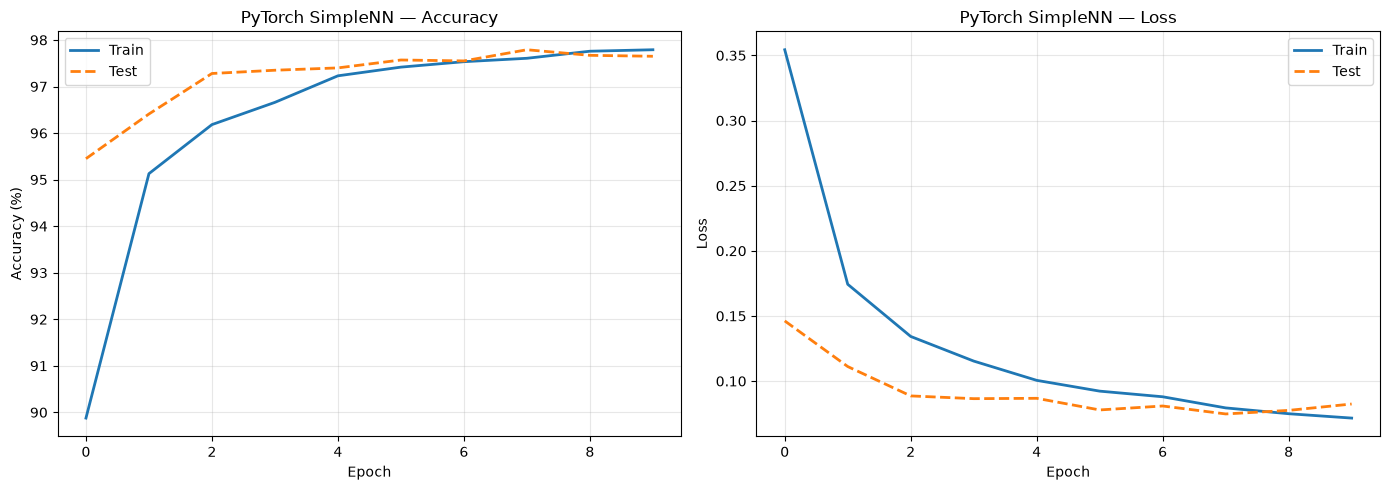

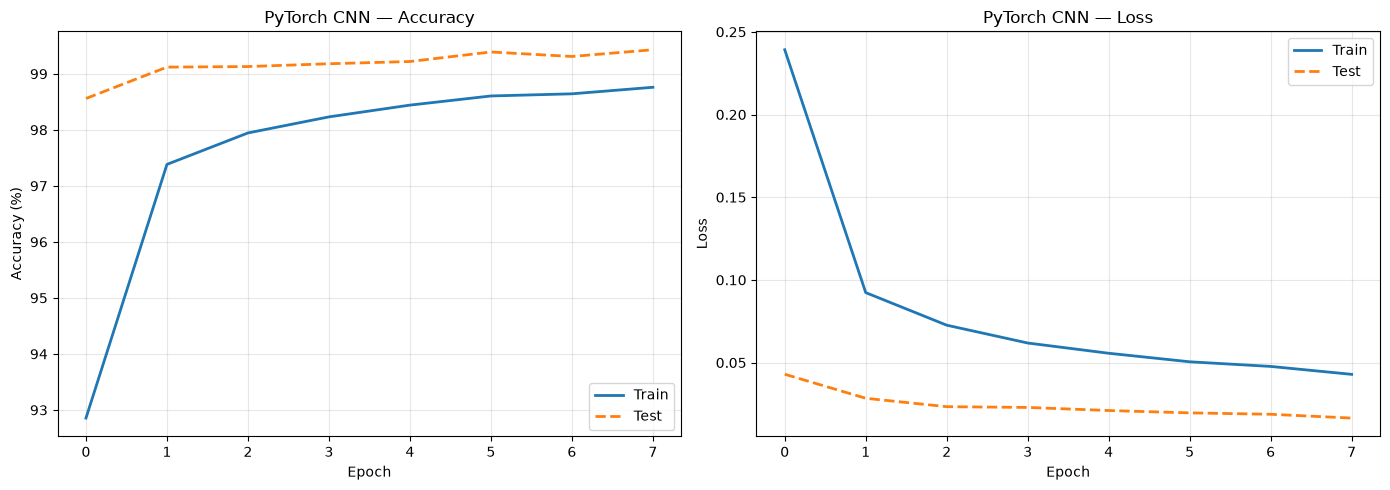

In [31]:
def plot_pt_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0].plot(history['test_acc'],  label='Test',  linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_loss'], label='Train', linewidth=2)
    axes[1].plot(history['test_loss'],  label='Test',  linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} — Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_pt_history(hist_simple_pt, 'PyTorch SimpleNN')
plot_pt_history(hist_cnn_pt,    'PyTorch CNN')


PyTorch SimpleNN — Test Accuracy: 97.65%


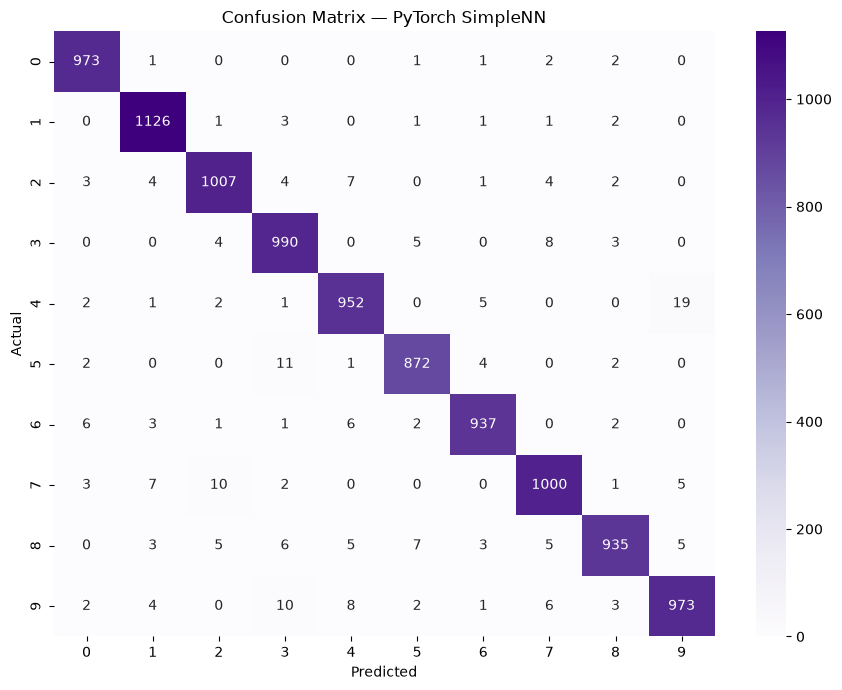

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


PyTorch CNN — Test Accuracy: 99.43%


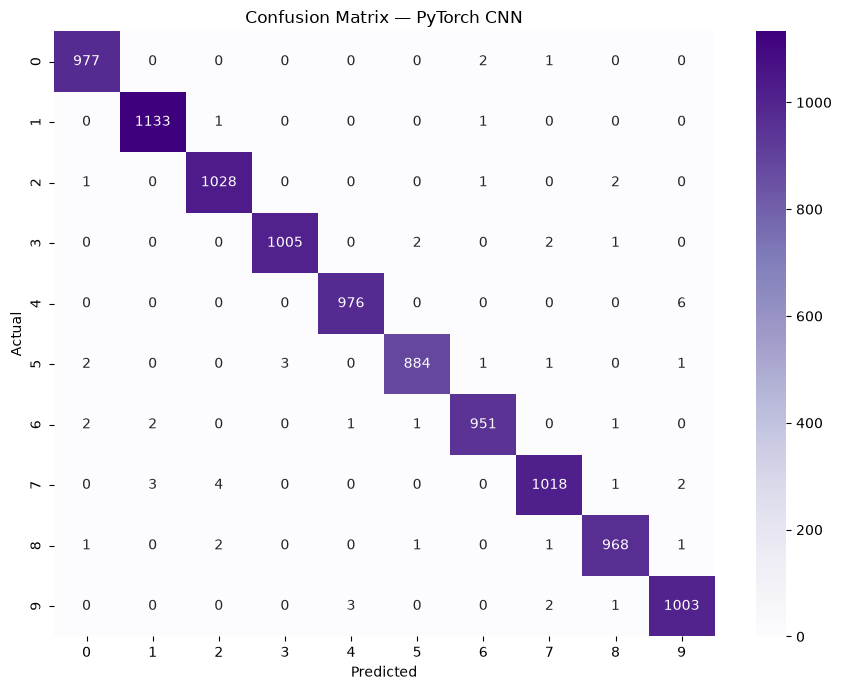

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [32]:
criterion = nn.CrossEntropyLoss()

def evaluate_pytorch(model, loader, model_name):
    _, acc, preds, targets = eval_epoch(model, loader, criterion)
    print(f'\n{model_name} — Test Accuracy: {acc:.2f}%')

    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=range(10), yticklabels=range(10))
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    print(classification_report(targets, preds))
    return acc

acc_simple_pt = evaluate_pytorch(simple_nn, test_loader, 'PyTorch SimpleNN')
acc_cnn_pt    = evaluate_pytorch(cnn_pt,    test_loader, 'PyTorch CNN')

# Hyperparameter Tuning with PyTorch

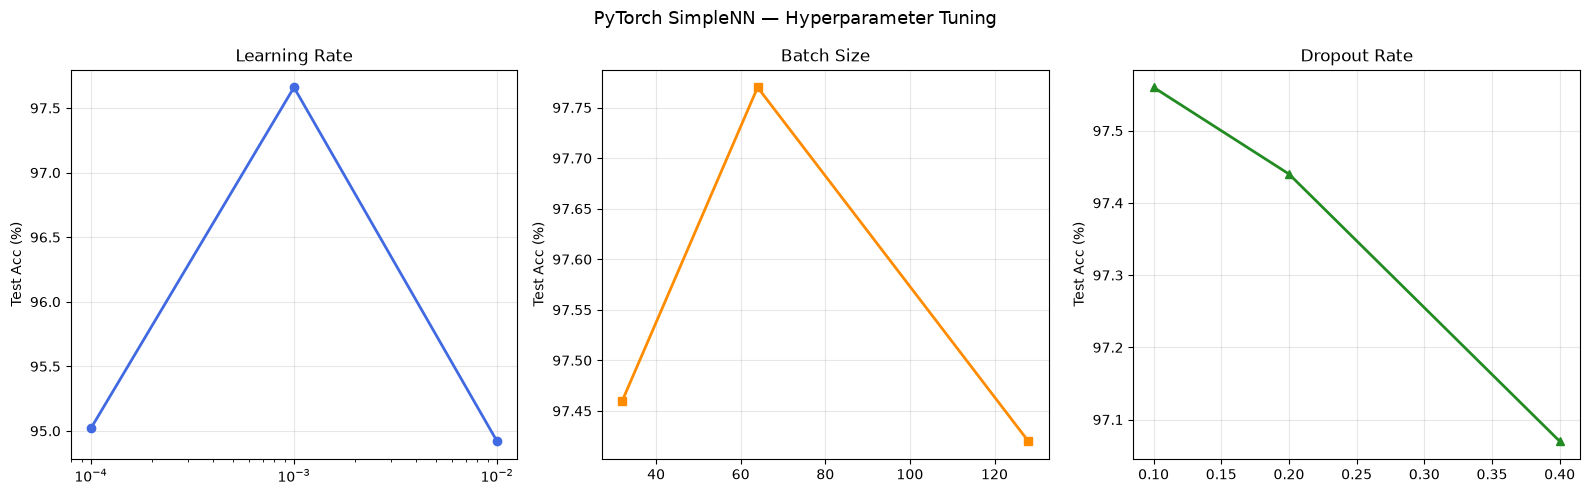

In [33]:
def quick_train_pytorch(lr=0.001, batch_size=64, dropout=0.2, epochs=5):
    model = SimpleNN(dropout=dropout).to(device)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(model.parameters(), lr=lr)
    best_acc = 0
    for _ in range(epochs):
        train_epoch(model, loader, opt, crit)
        _, acc, _, _ = eval_epoch(model, test_loader, crit)
        best_acc = max(best_acc, acc)
    return best_acc

lr_pt  = {lr: quick_train_pytorch(lr=lr)          for lr in [0.01, 0.001, 0.0001]}
bs_pt  = {bs: quick_train_pytorch(batch_size=bs)  for bs in [32, 64, 128]}
dr_pt  = {dr: quick_train_pytorch(dropout=dr)     for dr in [0.1, 0.2, 0.4]}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(list(lr_pt.keys()), list(lr_pt.values()), 'o-', linewidth=2, color='royalblue')
axes[0].set_xscale('log'); axes[0].set_title('Learning Rate'); axes[0].set_ylabel('Test Acc (%)'); axes[0].grid(alpha=0.3)
axes[1].plot(list(bs_pt.keys()), list(bs_pt.values()), 's-', linewidth=2, color='darkorange')
axes[1].set_title('Batch Size'); axes[1].set_ylabel('Test Acc (%)'); axes[1].grid(alpha=0.3)
axes[2].plot(list(dr_pt.keys()), list(dr_pt.values()), '^-', linewidth=2, color='forestgreen')
axes[2].set_title('Dropout Rate'); axes[2].set_ylabel('Test Acc (%)'); axes[2].grid(alpha=0.3)
plt.suptitle('PyTorch SimpleNN — Hyperparameter Tuning', fontsize=13)
plt.tight_layout(); plt.show()

---
## Final Model Comparison

Summary of all four models across both frameworks.

Framework    Model  Test Acc (%)
  PyTorch      CNN         99.43
    Keras      CNN         99.35
    Keras     FFNN         97.87
  PyTorch SimpleNN         97.65


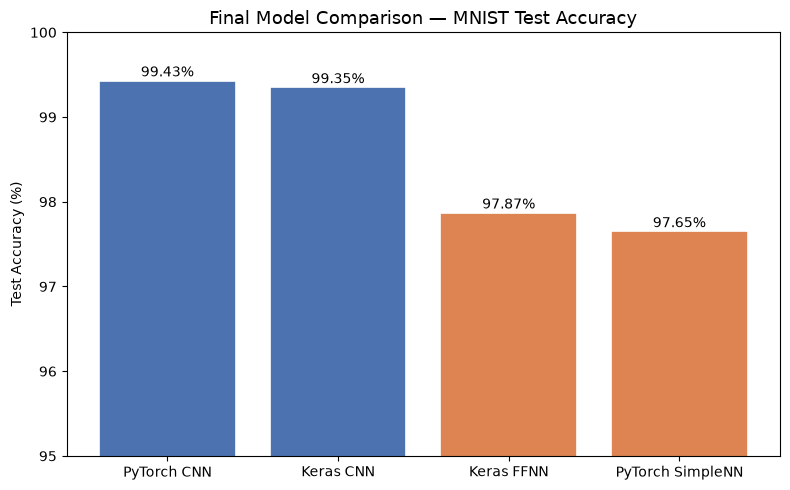

In [34]:
comparison = pd.DataFrame({
    'Framework': ['Keras', 'Keras', 'PyTorch', 'PyTorch'],
    'Model':     ['FFNN',  'CNN',   'SimpleNN','CNN'],
    'Test Acc (%)': [
        round(acc_ffnn_keras * 100, 2),
        round(acc_cnn_keras  * 100, 2),
        round(acc_simple_pt,        2),
        round(acc_cnn_pt,           2)
    ]
})
comparison = comparison.sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 5))
colors = ['#4C72B0','#4C72B0','#DD8452','#DD8452']
bars = plt.bar(comparison['Framework'] + ' ' + comparison['Model'],
               comparison['Test Acc (%)'], color=colors, edgecolor='white', linewidth=1.2)
plt.ylim(95, 100)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.2f}%', ha='center', fontsize=10)
plt.title('Final Model Comparison — MNIST Test Accuracy', fontsize=13)
plt.ylabel('Test Accuracy (%)')
plt.tight_layout()
plt.show()

# Save Best Model 

In [35]:
# Save Keras models
keras_ffnn.save('keras_ffnn_mnist.keras')
keras_cnn.save('keras_cnn_mnist.keras')
print('Keras models saved.')

# Save PyTorch models
torch.save(simple_nn.state_dict(), 'pytorch_simplenn_mnist.pth')
torch.save(cnn_pt.state_dict(),    'pytorch_cnn_mnist.pth')
print('PyTorch models saved.')

Keras models saved.
PyTorch models saved.
